<a href="https://colab.research.google.com/github/sayandeepmaity/luminator/blob/main/gunshot_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import os

In [38]:
# 1. Generate a larger, more varied synthetic dataset
np.random.seed(42)
n_samples = 100_000  # total samples

# Class 0: non-gunshot
non_gunshot = pd.DataFrame({
    'correlation': np.random.normal(0.3, 0.15, n_samples // 2),
    'phase': np.random.normal(0.2, 0.15, n_samples // 2),
    'amplitude': np.random.normal(2, 0.7, n_samples // 2),
    'energy': np.random.normal(2, 0.7, n_samples // 2),
    'spectral_centroid': np.random.normal(1000, 400, n_samples // 2),
    'snr': np.random.normal(5, 3, n_samples // 2),
    'label': 0
})

# Class 1: gunshot
gunshot = pd.DataFrame({
    'correlation': np.clip(np.random.normal(0.8, 0.15, n_samples // 2), 0, 1),
    'phase': np.clip(np.random.normal(0.7, 0.15, n_samples // 2), 0, 1),
    'amplitude': np.random.normal(5, 1.5, n_samples // 2),
    'energy': np.random.normal(5, 1.5, n_samples // 2),
    'spectral_centroid': np.random.normal(2000, 500, n_samples // 2),
    'snr': np.random.normal(20, 7, n_samples // 2),
    'label': 1
})

# Combine and shuffle
df = pd.concat([non_gunshot, gunshot]).sample(frac=1, random_state=42).reset_index(drop=True)

# Show a quick sample
print("Sample of the generated dataset:")
display(df.sample(5))

# 2. Mount Google Drive and save CSV
# Note: run this in a Colab environment or anywhere you can mount Drive
from google.colab import drive
drive.mount('/content/drive')

output_dir = '/content/drive/My Drive/gunshotdata'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, 'syntheticdataformodel1.csv')

df.to_csv(file_path, index=False)
print(f"Synthetic dataset saved to: {file_path}")


Sample of the generated dataset:


,correlation,phase,amplitude,energy,spectral_centroid,snr,label
13517,0.259445,0.254056,1.723650,0.979986,1473.499778,4.497914,0
42627,0.292400,0.434144,2.143100,2.539407,861.133310,0.144184,0
42687,0.978902,0.660567,5.456174,6.204372,1843.941508,17.652997,1
5095,0.930796,0.697412,5.241113,4.348358,3002.183958,18.562023,1
71464,0.541283,-0.171597,1.952267,1.359360,1548.980979,0.558326,0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Synthetic dataset saved to: /content/drive/My Drive/gunshotdata/syntheticdataformodel1.csv


In [40]:
import numpy as np
import pandas as pd
from scipy.signal import correlate, periodogram

def generate_synthetic_core(n_samples, seed=42):
    """Generate the core ML features (corr, phase, amp, energy, spec_centroid, SNR, label)."""
    np.random.seed(seed)
    half = n_samples // 2

    # non-gunshot
    non_gun = pd.DataFrame({
        'correlation': np.random.normal(0.3, 0.15, half),
        'phase':       np.random.normal(0.2, 0.15, half),
        'amplitude':   np.random.normal(2,   0.7,  half),
        'energy':      np.random.normal(2,   0.7,  half),
        'spectral_centroid': np.random.normal(1000, 400, half),
        'snr':         np.random.normal(5,   3,    half),
        'label':      0
    })

    # gunshot
    gun = pd.DataFrame({
        'correlation': np.clip(np.random.normal(0.8, 0.15, half), 0, 1),
        'phase':       np.clip(np.random.normal(0.7, 0.15, half), 0, 1),
        'amplitude':   np.random.normal(5,   1.5,  half),
        'energy':      np.random.normal(5,   1.5,  half),
        'spectral_centroid': np.random.normal(2000, 500, half),
        'snr':         np.random.normal(20,  7,    half),
        'label':      1
    })

    # combine & shuffle
    df = pd.concat([non_gun, gun], axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

def simulate_tdoas(n_samples, n_sensors=4, max_delay=0.001, fs=48000):
    delays = np.random.uniform(-max_delay, max_delay, size=(n_samples, n_sensors))
    tdoas = np.round(delays * fs).astype(int)
    return pd.DataFrame(tdoas, columns=[f"tdoa_s{i}" for i in range(n_sensors)])

def cross_corr_features(waveforms):
    feats = {}
    n = waveforms.shape[1]
    for i in range(len(waveforms)):
        for j in range(i+1, len(waveforms)):
            corr = correlate(waveforms[i], waveforms[j], mode='valid')
            feats[f"xcorr_{i}{j}_max"] = corr.max()
            feats[f"xcorr_{i}{j}_lag"] = corr.argmax() - (n-1)
    return feats

def spectral_feats(signal, fs=48000):
    f, Pxx = periodogram(signal, fs)
    centroid = (f * Pxx).sum() / Pxx.sum()
    cumulative = np.cumsum(Pxx) / Pxx.sum()
    rolloff = f[np.searchsorted(cumulative, 0.85)]
    bandwidth = np.sqrt(((f-centroid)**2 * Pxx).sum() / Pxx.sum())
    return {
        "spec_centroid": centroid,
        "spec_rolloff85": rolloff,
        "spec_bandwidth": bandwidth
    }

# --- now assemble your full feature DataFrame ---

n = 10000
base = generate_synthetic_core(n)

tdoa_df = simulate_tdoas(n)

# if you only want one set of xcorr/spectral feats per sample,
# you’d loop or vectorize this over true per-sample waveforms;
# for demo purposes here we compute once and broadcast:
waveforms = np.random.randn(4, 1024)
xc = cross_corr_features(waveforms)
sf = spectral_feats(np.random.randn(1024))

# combine everything
df = pd.concat([base, tdoa_df], axis=1)
for feat_name, feat_val in {**xc, **sf}.items():
    df[feat_name] = feat_val

print(df.shape)
display(df.head())


(10000, 26)


,correlation,phase,amplitude,energy,spectral_centroid,snr,label,tdoa_s0,tdoa_s1,tdoa_s2,...,xcorr_03_lag,xcorr_12_max,xcorr_12_lag,xcorr_13_max,xcorr_13_lag,xcorr_23_max,xcorr_23_lag,spec_centroid,spec_rolloff85,spec_bandwidth
0,0.594826,0.645185,3.461604,5.956144,2165.546791,13.336935,1,-29,43,44,...,-1023,-13.719754,-1023,35.294349,-1023,-2.219901,-1023,12204.627038,20671.875,7099.793848
1,0.144440,0.083029,1.476945,0.966890,1435.728543,3.813571,0,-30,8,41,...,-1023,-13.719754,-1023,35.294349,-1023,-2.219901,-1023,12204.627038,20671.875,7099.793848
2,0.247602,0.067420,3.712039,1.849101,1686.430379,5.251678,0,-35,19,15,...,-1023,-13.719754,-1023,35.294349,-1023,-2.219901,-1023,12204.627038,20671.875,7099.793848
3,0.300243,-0.019045,2.338051,1.307435,912.078918,4.132495,0,34,15,-29,...,-1023,-13.719754,-1023,35.294349,-1023,-2.219901,-1023,12204.627038,20671.875,7099.793848
4,0.461150,0.497371,2.107554,1.896911,329.162177,2.727234,0,45,24,-13,...,-1023,-13.719754,-1023,35.294349,-1023,-2.219901,-1023,12204.627038,20671.875,7099.793848


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Step 1: Load the dataset
file_path = '/content/drive/My Drive/gunshotdata/syntheticdataformodel1.csv'
df = pd.read_csv(file_path)

# Step 2: Split the data into features (X) and labels (y)
X = df.drop('label', axis=1)  # Drop the label column for features
y = df['label']  # The label column is the target

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Save the split data to the specified directories
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Save the training and test sets to the new location
train_data_path = '/content/drive/My Drive/gunshotdata/dmodel1/train_data.csv'
test_data_path = '/content/drive/My Drive/gunshotdata/dmodel1/test_data.csv'

train_data.to_csv(train_data_path, index=False)
test_data.to_csv(test_data_path, index=False)

print(f"Training data saved to: {train_data_path}")
print(f"Test data saved to: {test_data_path}")

Training data saved to: /content/drive/My Drive/gunshotdata/dmodel1/train_data.csv
Test data saved to: /content/drive/My Drive/gunshotdata/dmodel1/test_data.csv


In [44]:
# Step 5: Train the model (Random Forest Classifier as an example)
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = clf.predict(X_test)

# Print accuracy and classification report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Step 7: Save the trained model
model_path = '/content/drive/My Drive/gunshotdata/dmodel1/gunshot_classifier_model.pkl'
joblib.dump(clf, model_path)

print(f"Trained model saved to: {model_path}")

Accuracy: 0.9999
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9922
           1       1.00      1.00      1.00     10078

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Trained model saved to: /content/drive/My Drive/gunshotdata/dmodel1/gunshot_classifier_model.pkl


In [45]:
import joblib
import pandas as pd

# Load the trained model
model_path = '/content/drive/My Drive/gunshotdata/dmodel1/gunshot_classifier_model.pkl'
clf = joblib.load(model_path)

# Example: Make predictions on new data (use a sample row or test data)
# Load new data (for example, a new test file)
new_data_path = '/content/drive/My Drive/gunshotdata/dmodel1/test_data.csv'
new_data = pd.read_csv(new_data_path)

# Extract features from the new data (ensure it matches the format)
X_new = new_data.drop('label', axis=1)

# Predict with the loaded model
predictions = clf.predict(X_new)

# Output the predictions
print(predictions)


[0 1 1 ... 1 0 1]


In [46]:
import numpy as np
import pandas as pd

# assume `predictions` is your array and `new_data` is the DataFrame you loaded
# 1. Count predictions per class
unique, counts = np.unique(predictions, return_counts=True)
print("Prediction counts:", dict(zip(unique, counts)))
# e.g. {0:  9922, 1: 10078}

# 2. Create a results DataFrame
results_df = new_data.copy()
results_df['prediction'] = predictions

# 3. (Optional) Save to CSV
output_path = '/content/drive/My Drive/gunshotdata/dmodel1/test_data_with_preds.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

# 4. Quick peek
results_df.head()


Prediction counts: {np.int64(0): np.int64(9920), np.int64(1): np.int64(10080)}
Results saved to: /content/drive/My Drive/gunshotdata/dmodel1/test_data_with_preds.csv


,correlation,phase,amplitude,energy,spectral_centroid,snr,label,prediction
0,0.413984,0.350258,2.195875,2.967819,1251.650656,3.432899,0,0
1,1.000000,0.900997,5.834156,6.944084,2579.240144,14.294404,1,1
2,0.638201,0.578347,4.290397,8.809213,1509.038904,10.324900,1,1
3,0.226335,0.209081,1.741627,2.039666,1080.354218,8.318147,0,0
4,0.846722,0.497426,5.430200,6.354830,2038.735867,15.540356,1,1


In [47]:
misclassifications = results_df[results_df['label'] != results_df['prediction']]
print(f"Number of misclassifications: {misclassifications.shape[0]}")


Number of misclassifications: 2


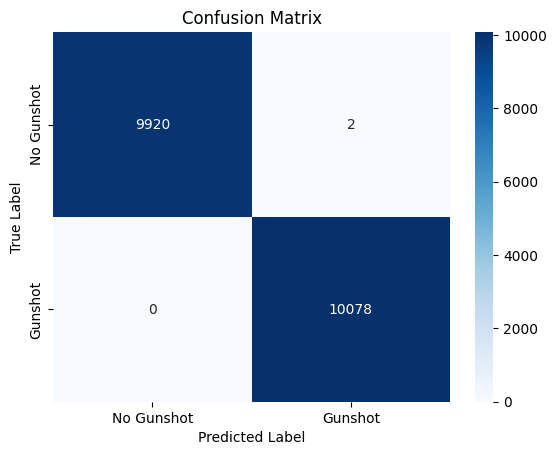

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(results_df['label'], results_df['prediction'])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Gunshot", "Gunshot"], yticklabels=["No Gunshot", "Gunshot"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [49]:
from sklearn.metrics import classification_report
print(classification_report(results_df['label'], results_df['prediction']))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9922
           1       1.00      1.00      1.00     10078

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

